# Student Dropout Prediction Project

## Notebook 04: Model Evaluation and Hyperparameter Tuning

### Objective

This notebook builds on the baseline models from Notebook 03.

The goals are to:

1. Evaluate baseline model performance using class-level metrics.
2. Tune the baseline models using cross-validation on the training data only.
3. Compare tuned models with their corresponding baseline models.
4. Evaluate the tuned models once on the held-out test sets.
5. Examine whether tuning changes the prediction of the three student outcomes.

Two prediction stages are maintained:

- **Enrollment-only prediction**
- **Semester 1 prediction**

The target variable contains:

- Dropout
- Enrolled
- Graduate

Macro F1 is used as the main cross-validation scoring metric because the target classes are not equally represented.


## 1. Import libraries


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 2. Load the processed datasets


In [24]:
enrollment_df = pd.read_csv("../data/processed/enrollment_only.csv")
semester1_df = pd.read_csv("../data/processed/semester1.csv")

print("Enrollment-only shape:", enrollment_df.shape)
print("Semester 1 shape:", semester1_df.shape)


Enrollment-only shape: (4424, 25)
Semester 1 shape: (4424, 31)


## 3. Separate features and target


In [25]:
X_enrollment = enrollment_df.drop(columns=["Target"])
y_enrollment = enrollment_df["Target"]

X_semester1 = semester1_df.drop(columns=["Target"])
y_semester1 = semester1_df["Target"]

print("Enrollment-only features:", X_enrollment.shape)
print("Semester 1 features:", X_semester1.shape)


Enrollment-only features: (4424, 24)
Semester 1 features: (4424, 30)


## 4. Define categorical and numerical variables

Categorical-coded variables are one-hot encoded. Continuous numerical variables are standardized.

The first-semester academic variables are added only to the Semester 1 stage.


In [26]:
categorical_cols = [
    "Marital Status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

numerical_cols = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment"
]

semester1_numerical_cols = numerical_cols + [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)"
]


## 5. Train-test split

The test set is held out from model selection.

All hyperparameter tuning is performed using cross-validation on the training set. The test set is used only for the final evaluation of the selected model configurations.


In [27]:
X_train_enrollment, X_test_enrollment, y_train_enrollment, y_test_enrollment = train_test_split(
    X_enrollment,
    y_enrollment,
    test_size=0.20,
    random_state=42,
    stratify=y_enrollment
)

X_train_semester1, X_test_semester1, y_train_semester1, y_test_semester1 = train_test_split(
    X_semester1,
    y_semester1,
    test_size=0.20,
    random_state=42,
    stratify=y_semester1
)

print("Enrollment-only training:", X_train_enrollment.shape)
print("Enrollment-only testing:", X_test_enrollment.shape)
print("Semester 1 training:", X_train_semester1.shape)
print("Semester 1 testing:", X_test_semester1.shape)


Enrollment-only training: (3539, 24)
Enrollment-only testing: (885, 24)
Semester 1 training: (3539, 30)
Semester 1 testing: (885, 30)


## 6. Create preprocessing pipelines

The preprocessing is included inside each model pipeline.

This prevents information from the test set from being used during preprocessing or cross-validation.


In [28]:
def make_preprocessor(numerical_features):
    return ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_cols
            ),
            (
                "num",
                StandardScaler(),
                numerical_features
            )
        ]
    )

enrollment_preprocessor = make_preprocessor(numerical_cols)
semester1_preprocessor = make_preprocessor(semester1_numerical_cols)


## 7. Cross-validation setup

Five-fold stratified cross-validation is used.

Each fold keeps approximately the same class proportions as the training data.

The scoring metric for model selection is **Macro F1**.


In [29]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


## 8. Baseline model configurations

These reproduce the baseline model configurations from Notebook 03 so that tuned results can be compared with the original baselines.


In [30]:
baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}


## 9. Define tuning grids

The grids are deliberately small enough to keep the experiment practical.

`class_weight="balanced"` is included as an option because the three target classes have different frequencies. The purpose is to test whether weighting classes changes macro F1 and class-level recall.

The test set is not used during this search.


In [31]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1.0, 10.0],
        "model__class_weight": [None, "balanced"]
    },
    "Decision Tree": {
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_leaf": [1, 5, 10],
        "model__class_weight": [None, "balanced"]
    },
    "Random Forest": {
        "model__n_estimators": [200, 300],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_leaf": [1, 5],
        "model__class_weight": [None, "balanced"]
    }
}


## 10. Function for baseline evaluation


In [32]:
def evaluate_predictions(y_true, predictions):
    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Macro Precision": precision_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true, predictions, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_true, predictions, average="macro", zero_division=0
        )
    }


## 11. Evaluate Enrollment-only baseline models


In [33]:
baseline_enrollment_results = []

for model_name, model in baseline_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", enrollment_preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train_enrollment, y_train_enrollment)
    predictions = pipeline.predict(X_test_enrollment)

    metrics = evaluate_predictions(
        y_test_enrollment,
        predictions
    )

    baseline_enrollment_results.append({
        "Prediction Stage": "Enrollment-only",
        "Model": model_name,
        **metrics
    })

baseline_enrollment_df = pd.DataFrame(baseline_enrollment_results)
display(baseline_enrollment_df.round(4))


,Prediction Stage,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Enrollment-only,Logistic Regression,0.6237,0.5281,0.5127,0.5060
1,Enrollment-only,Decision Tree,0.5220,0.4679,0.4660,0.4666
2,Enrollment-only,Random Forest,0.6215,0.5294,0.5022,0.4848


## 12. Evaluate Semester 1 baseline models


In [34]:
baseline_semester1_results = []

for model_name, model in baseline_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", semester1_preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train_semester1, y_train_semester1)
    predictions = pipeline.predict(X_test_semester1)

    metrics = evaluate_predictions(
        y_test_semester1,
        predictions
    )

    baseline_semester1_results.append({
        "Prediction Stage": "Semester 1",
        "Model": model_name,
        **metrics
    })

baseline_semester1_df = pd.DataFrame(baseline_semester1_results)
display(baseline_semester1_df.round(4))


,Prediction Stage,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Semester 1,Logistic Regression,0.7379,0.6651,0.6426,0.6465
1,Semester 1,Decision Tree,0.6610,0.5995,0.6006,0.5999
2,Semester 1,Random Forest,0.7186,0.6284,0.5988,0.5925


## 13. Tune Enrollment-only models

Each model is tuned independently.

The selected configuration is based on the mean five-fold cross-validated Macro F1 on the training data.


In [35]:
tuned_enrollment_models = {}
tuned_enrollment_predictions = {}
tuned_enrollment_results = []
enrollment_cv_results = {}

for model_name, model in baseline_models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", enrollment_preprocessor),
            ("model", model)
        ]
    )

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(
        X_train_enrollment,
        y_train_enrollment
    )

    predictions = grid_search.predict(X_test_enrollment)
    metrics = evaluate_predictions(
        y_test_enrollment,
        predictions
    )

    tuned_enrollment_models[model_name] = grid_search.best_estimator_
    tuned_enrollment_predictions[model_name] = predictions
    enrollment_cv_results[model_name] = grid_search.cv_results_

    tuned_enrollment_results.append({
        "Prediction Stage": "Enrollment-only",
        "Model": model_name,
        "Best CV Macro F1": grid_search.best_score_,
        "Accuracy": metrics["Accuracy"],
        "Macro Precision": metrics["Macro Precision"],
        "Macro Recall": metrics["Macro Recall"],
        "Macro F1": metrics["Macro F1"]
    })

tuned_enrollment_df = pd.DataFrame(tuned_enrollment_results)

display(tuned_enrollment_df.round(4))


,Prediction Stage,Model,Best CV Macro F1,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Enrollment-only,Logistic Regression,0.5638,0.5627,0.5479,0.5463,0.5359
1,Enrollment-only,Decision Tree,0.5125,0.5107,0.5537,0.5335,0.5033
2,Enrollment-only,Random Forest,0.5726,0.5864,0.5442,0.5468,0.5432


## 14. Best Enrollment-only configurations

The following table shows which hyperparameter combination was selected by cross-validation for each model.

This is a description of the search result, not a claim that one model is universally superior.


In [36]:
for model_name, cv_results in enrollment_cv_results.items():
    results = pd.DataFrame(cv_results)
    best_row = results.loc[results["rank_test_score"].idxmin()]

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print("Best parameters:")
    print(best_row["params"])
    print("Best mean CV Macro F1:", round(best_row["mean_test_score"], 4))


Logistic Regression
Best parameters:
{'model__C': 1.0, 'model__class_weight': 'balanced'}
Best mean CV Macro F1: 0.5638
Decision Tree
Best parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 1}
Best mean CV Macro F1: 0.5125
Random Forest
Best parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best mean CV Macro F1: 0.5726


## 15. Tune Semester 1 models

The same tuning procedure is applied to the Semester 1 stage.


In [37]:
tuned_semester1_models = {}
tuned_semester1_predictions = {}
tuned_semester1_results = []
semester1_cv_results = {}

for model_name, model in baseline_models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", semester1_preprocessor),
            ("model", model)
        ]
    )

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    grid_search.fit(
        X_train_semester1,
        y_train_semester1
    )

    predictions = grid_search.predict(X_test_semester1)
    metrics = evaluate_predictions(
        y_test_semester1,
        predictions
    )

    tuned_semester1_models[model_name] = grid_search.best_estimator_
    tuned_semester1_predictions[model_name] = predictions
    semester1_cv_results[model_name] = grid_search.cv_results_

    tuned_semester1_results.append({
        "Prediction Stage": "Semester 1",
        "Model": model_name,
        "Best CV Macro F1": grid_search.best_score_,
        "Accuracy": metrics["Accuracy"],
        "Macro Precision": metrics["Macro Precision"],
        "Macro Recall": metrics["Macro Recall"],
        "Macro F1": metrics["Macro F1"]
    })

tuned_semester1_df = pd.DataFrame(tuned_semester1_results)

display(tuned_semester1_df.round(4))


,Prediction Stage,Model,Best CV Macro F1,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Semester 1,Logistic Regression,0.6770,0.7107,0.6819,0.6829,0.6732
1,Semester 1,Decision Tree,0.6253,0.6056,0.6387,0.6114,0.5905
2,Semester 1,Random Forest,0.6856,0.7096,0.6553,0.6516,0.6521


## 16. Best Semester 1 configurations


In [38]:
for model_name, cv_results in semester1_cv_results.items():
    results = pd.DataFrame(cv_results)
    best_row = results.loc[results["rank_test_score"].idxmin()]

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print("Best parameters:")
    print(best_row["params"])
    print("Best mean CV Macro F1:", round(best_row["mean_test_score"], 4))


Logistic Regression
Best parameters:
{'model__C': 0.1, 'model__class_weight': 'balanced'}
Best mean CV Macro F1: 0.677
Decision Tree
Best parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 10}
Best mean CV Macro F1: 0.6253
Random Forest
Best parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best mean CV Macro F1: 0.6856


## 17. Compare baseline and tuned performance

The comparison shows how the selected hyperparameter configurations changed the held-out test metrics.

The comparison should be interpreted model-by-model and stage-by-stage.


In [39]:
baseline_all = pd.concat(
    [baseline_enrollment_df, baseline_semester1_df],
    ignore_index=True
)

tuned_all = pd.concat(
    [tuned_enrollment_df, tuned_semester1_df],
    ignore_index=True
)

baseline_all["Model Type"] = "Baseline"
tuned_all["Model Type"] = "Tuned"

comparison = pd.concat(
    [baseline_all, tuned_all],
    ignore_index=True
)

comparison = comparison[
    [
        "Prediction Stage",
        "Model",
        "Model Type",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
]

display(comparison.round(4))


,Prediction Stage,Model,Model Type,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Enrollment-only,Logistic Regression,Baseline,0.6237,0.5281,0.5127,0.5060
1,Enrollment-only,Decision Tree,Baseline,0.5220,0.4679,0.4660,0.4666
2,Enrollment-only,Random Forest,Baseline,0.6215,0.5294,0.5022,0.4848
3,Semester 1,Logistic Regression,Baseline,0.7379,0.6651,0.6426,0.6465
4,Semester 1,Decision Tree,Baseline,0.6610,0.5995,0.6006,0.5999
5,Semester 1,Random Forest,Baseline,0.7186,0.6284,0.5988,0.5925
6,Enrollment-only,Logistic Regression,Tuned,0.5627,0.5479,0.5463,0.5359
7,Enrollment-only,Decision Tree,Tuned,0.5107,0.5537,0.5335,0.5033
8,Enrollment-only,Random Forest,Tuned,0.5864,0.5442,0.5468,0.5432
9,Semester 1,Logistic Regression,Tuned,0.7107,0.6819,0.6829,0.6732


## 18. Class-level evaluation of tuned models

Overall metrics can hide differences between classes, so classification reports are examined for each tuned model.


In [40]:
print("ENROLLMENT-ONLY TUNED MODELS")
print("=" * 80)

for model_name, predictions in tuned_enrollment_predictions.items():
    print("\n" + model_name)
    print(
        classification_report(
            y_test_enrollment,
            predictions,
            labels=["Dropout", "Enrolled", "Graduate"],
            zero_division=0
        )
    )

print("\nSEMESTER 1 TUNED MODELS")
print("=" * 80)

for model_name, predictions in tuned_semester1_predictions.items():
    print("\n" + model_name)
    print(
        classification_report(
            y_test_semester1,
            predictions,
            labels=["Dropout", "Enrolled", "Graduate"],
            zero_division=0
        )
    )


ENROLLMENT-ONLY TUNED MODELS

Logistic Regression
              precision    recall  f1-score   support

     Dropout       0.65      0.59      0.62       284
    Enrolled       0.28      0.47      0.35       159
    Graduate       0.71      0.58      0.64       442

    accuracy                           0.56       885
   macro avg       0.55      0.55      0.54       885
weighted avg       0.62      0.56      0.58       885


Decision Tree
              precision    recall  f1-score   support

     Dropout       0.65      0.48      0.55       284
    Enrolled       0.26      0.64      0.37       159
    Graduate       0.75      0.49      0.59       442

    accuracy                           0.51       885
   macro avg       0.55      0.53      0.50       885
weighted avg       0.63      0.51      0.54       885


Random Forest
              precision    recall  f1-score   support

     Dropout       0.63      0.61      0.62       284
    Enrolled       0.30      0.39      0.34      

## 19. Confusion matrices for tuned Enrollment-only models


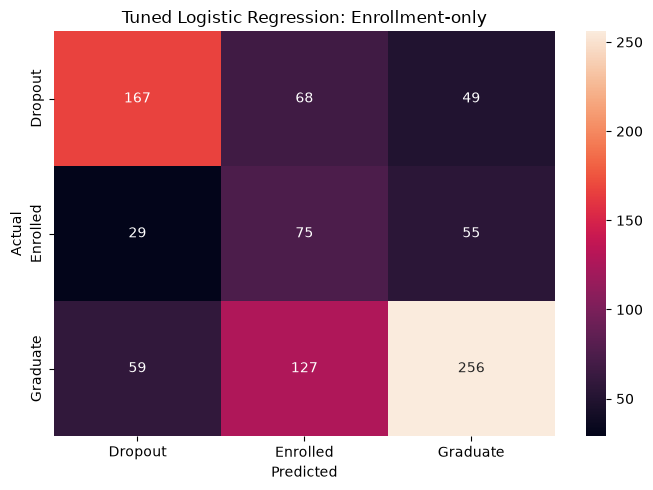

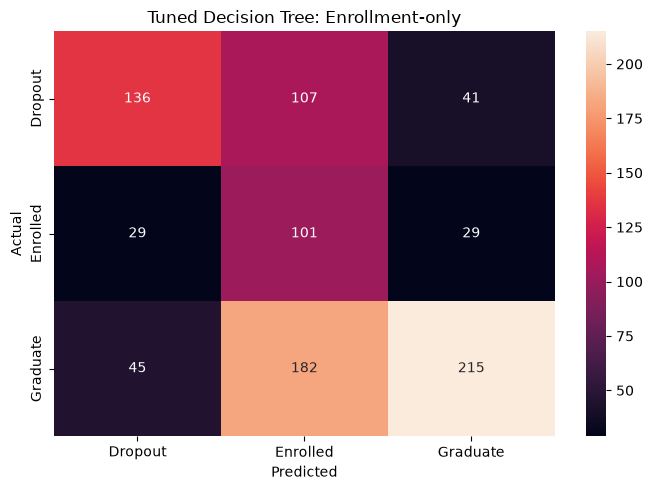

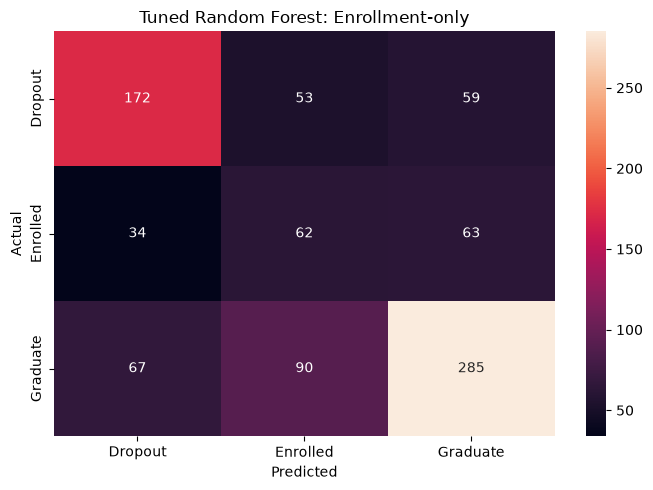

In [41]:
for model_name, predictions in tuned_enrollment_predictions.items():
    cm = confusion_matrix(
        y_test_enrollment,
        predictions,
        labels=["Dropout", "Enrolled", "Graduate"]
    )

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Dropout", "Enrolled", "Graduate"],
        yticklabels=["Dropout", "Enrolled", "Graduate"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Tuned {model_name}: Enrollment-only")
    plt.tight_layout()
    plt.show()


## 20. Confusion matrices for tuned Semester 1 models


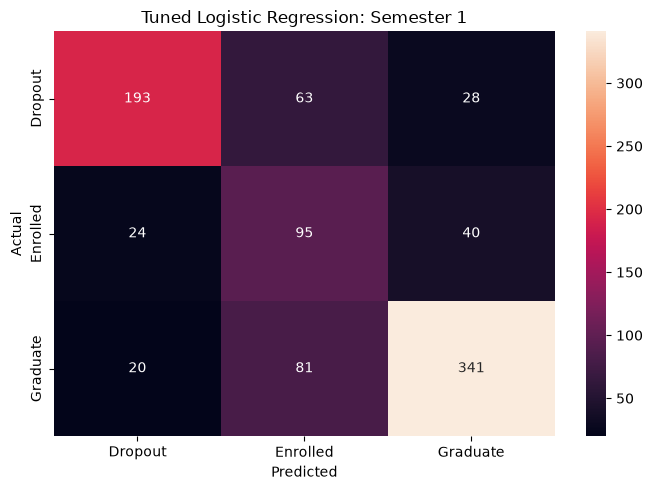

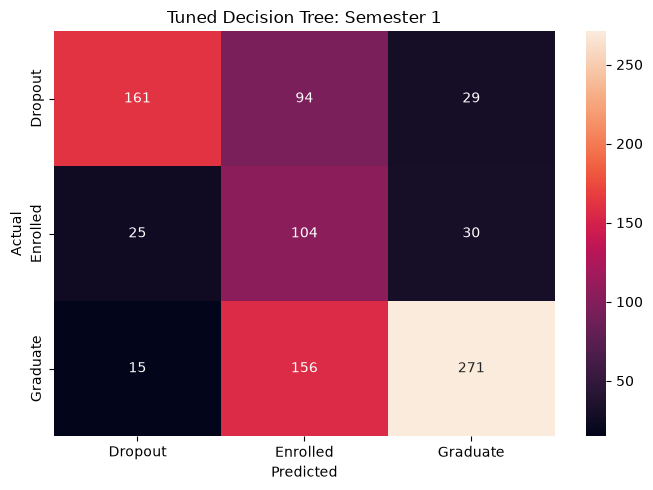

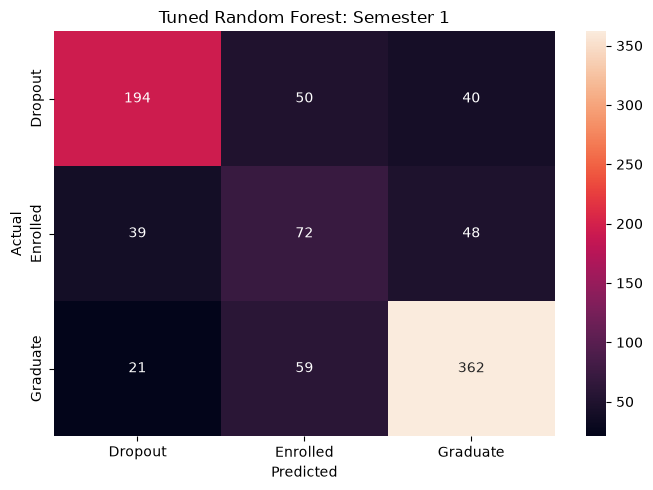

In [42]:
for model_name, predictions in tuned_semester1_predictions.items():
    cm = confusion_matrix(
        y_test_semester1,
        predictions,
        labels=["Dropout", "Enrolled", "Graduate"]
    )

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Dropout", "Enrolled", "Graduate"],
        yticklabels=["Dropout", "Enrolled", "Graduate"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Tuned {model_name}: Semester 1")
    plt.tight_layout()
    plt.show()


## 21. Change in Macro F1 after tuning

This table calculates the change between each baseline model and its tuned version.

A positive value means the tuned configuration had a higher held-out test Macro F1 than the baseline configuration for that same model and prediction stage.


In [43]:
baseline_keyed = baseline_all.set_index(
    ["Prediction Stage", "Model"]
)["Macro F1"]

tuned_keyed = tuned_all.set_index(
    ["Prediction Stage", "Model"]
)["Macro F1"]

f1_change = (
    tuned_keyed - baseline_keyed
).reset_index(name="Change in Macro F1")

display(f1_change.round(4))


,Prediction Stage,Model,Change in Macro F1
0,Enrollment-only,Logistic Regression,0.0300
1,Enrollment-only,Decision Tree,0.0368
2,Enrollment-only,Random Forest,0.0585
3,Semester 1,Logistic Regression,0.0268
4,Semester 1,Decision Tree,-0.0094
5,Semester 1,Random Forest,0.0597


## 22. Final baseline versus tuned results

This table contains the held-out test results used for the final discussion of this notebook.


In [44]:
final_results = pd.concat(
    [
        baseline_all.assign(Result="Baseline"),
        tuned_all.assign(Result="Tuned")
    ],
    ignore_index=True
)

final_results = final_results[
    [
        "Prediction Stage",
        "Model",
        "Result",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ]
]

display(final_results.round(4))


,Prediction Stage,Model,Result,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Enrollment-only,Logistic Regression,Baseline,0.6237,0.5281,0.5127,0.5060
1,Enrollment-only,Decision Tree,Baseline,0.5220,0.4679,0.4660,0.4666
2,Enrollment-only,Random Forest,Baseline,0.6215,0.5294,0.5022,0.4848
3,Semester 1,Logistic Regression,Baseline,0.7379,0.6651,0.6426,0.6465
4,Semester 1,Decision Tree,Baseline,0.6610,0.5995,0.6006,0.5999
5,Semester 1,Random Forest,Baseline,0.7186,0.6284,0.5988,0.5925
6,Enrollment-only,Logistic Regression,Tuned,0.5627,0.5479,0.5463,0.5359
7,Enrollment-only,Decision Tree,Tuned,0.5107,0.5537,0.5335,0.5033
8,Enrollment-only,Random Forest,Tuned,0.5864,0.5442,0.5468,0.5432
9,Semester 1,Logistic Regression,Tuned,0.7107,0.6819,0.6829,0.6732


## 23. Findings

### Finding 1: Hyperparameter tuning improved Macro F1 for most model-stage combinations

Hyperparameter tuning improved the held-out test Macro F1 for five of the six model-stage combinations.

For the Enrollment-only stage, Macro F1 increased from 0.5060 to 0.5359 for Logistic Regression, from 0.4666 to 0.5033 for Decision Tree, and from 0.4848 to 0.5432 for Random Forest.

For the Semester 1 stage, Macro F1 increased from 0.6465 to 0.6732 for Logistic Regression and from 0.5925 to 0.6521 for Random Forest. Decision Tree decreased slightly from 0.5999 to 0.5905.

### Finding 2: Class weighting was selected in all tuned models

The cross-validation search selected `class_weight="balanced"` for all three models in both prediction stages.

This indicates that accounting for the different frequencies of the three target classes was useful during model selection when Macro F1 was used as the scoring metric.

### Finding 3: Semester 1 information continues to provide additional predictive information

The tuned Semester 1 models achieved higher Macro F1 values than the tuned Enrollment-only models for all three algorithms.

The tuned Macro F1 values were:

- Logistic Regression: 0.6732
- Decision Tree: 0.5905
- Random Forest: 0.6521

For the Enrollment-only stage, the corresponding values were:

- Logistic Regression: 0.5359
- Decision Tree: 0.5033
- Random Forest: 0.5432

This supports the observation that first-semester academic information adds predictive information about the final student outcome.

### Finding 4: The Enrolled class became easier to identify after tuning

The tuned models generally showed improved recall for the Enrolled class compared with the baseline models.

For the tuned Semester 1 Logistic Regression model, recall for Enrolled was 0.60, compared with 0.28 for the corresponding baseline model.

This improvement is important because Enrolled was the most difficult class to identify in the baseline evaluation.

### Finding 5: Accuracy and Macro F1 can change in different directions

Some tuned models had lower accuracy than their baseline versions even though their Macro F1 increased.

This occurs because Macro F1 gives equal importance to each target class, whereas accuracy is strongly affected by the larger classes.

Therefore, both overall and class-level metrics are considered when evaluating model behavior.

### Finding 6: Cross-validation and held-out test performance should both be considered

The tuned models were selected using five-fold cross-validation on the training data, while the final reported metrics were calculated on the held-out test set.

For example, the Semester 1 Random Forest had a mean cross-validation Macro F1 of 0.6856 and a held-out test Macro F1 of 0.6521.

The difference between cross-validation and test performance indicates that performance estimates can vary across data splits, so the test result should be treated as the final held-out evaluation rather than assuming the cross-validation score will be reproduced exactly.

### Finding 7: The results establish the models for interpretation

The tuned models now provide a basis for the next stage of the project.

The next analysis will examine which features contribute most strongly to predictions and whether the important features differ between the Enrollment-only and Semester 1 prediction stages.

## 24. Important methodological notes

- Hyperparameters were selected using only the training data through five-fold stratified cross-validation.
- The held-out test set was not used for hyperparameter selection.
- Preprocessing is contained inside the model pipeline.
- Macro F1 is used for model selection because the target classes are imbalanced.
- Test performance should be interpreted together with class-level precision, recall, F1-score, and confusion matrices.
- This notebook evaluates predictive associations. It does not establish causal relationships between student characteristics and outcomes.


## 25. Next step

The next stage is model interpretation.

The selected model configurations can be examined using feature coefficients or feature importance, while keeping the prediction stage distinction clear.

The final project should report both what can be predicted at enrollment and what additional information becomes available after Semester 1.
